In [1]:
import os, sys, re, h5py
import numpy as np
from lib import NanonisAPI, MLAAPI
from lib import FileFunctions, DataProcessing
import time
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix
from python_tsp.exact import solve_tsp_dynamic_programming

file_functions = FileFunctions()
(hw_config, error) = file_functions.load_yaml("./sys/config.yml")

#nanonis = NanonisAPI(hw_config = hw_config, message_callback = lambda message, message_type: print(f"{message} [{message_type}]"), status_callback = lambda status_str: print(f"Status: {status_str}"))
#mla = MLAAPI(hw_config = hw_config, message_callback = lambda message, message_type: print(f"{message} [{message_type}]"), status_callback = lambda status_str: print(f"Status: {status_str}"))
#nhw = nanonis.nanonis_hardware
#data = DataProcessing()
#nanonis.link()

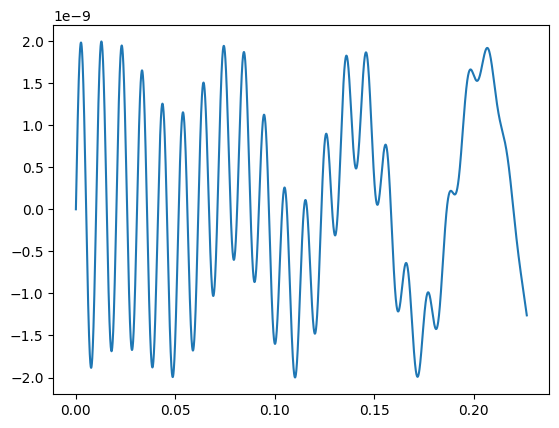

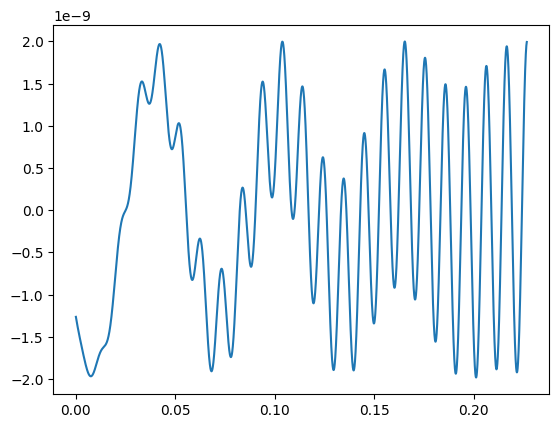

In [19]:
sample_rate = 44100

amplitudes = np.random.random((32))
amplitudes_old = np.random.random((32))
phases = np.zeros(32)
w = np.linspace(100, 16000, 32)

amplitudes = np.zeros((32), dtype = float)
amplitudes[0] = 1
amplitudes[1] = 0
amplitudes_old = np.zeros((32), dtype = float)
amplitudes_old[0] = 0
amplitudes_old[1] = 1

def callback(frames, phases):
    max_time = frames / sample_rate
    frac_list = np.arange(frames) / frames
    time_list = frac_list * max_time
    wave = np.zeros(frames)
    wnyquist = np.pi * sample_rate
    
    for i in range(32):
        wn = w[i]
        if wn > wnyquist: continue
        
        amp_old = 1E-8 * amplitudes_old[i]
        amp_new = 1E-8 * amplitudes[i]
        amp_envelope = np.linspace(amp_old, amp_new, len(time_list))
        wave_phase = np.sin(wn * time_list + phases[i])
        
        wave += amp_envelope * wave_phase
        phases[i] = (phases[i] + wn * max_time) % (2 * np.pi) # Update this harmonic's phase for the next block
    return (time_list, np.tanh(wave * 0.2)[:, np.newaxis], phases) # Soft-clipping to prevent digital distortion if harmonics sum too high

(time, wave, phases) = callback(10000, phases)
plt.plot(time, wave)
plt.show()

amplitudes = np.zeros((32), dtype = float)
amplitudes[0] = 0
amplitudes[1] = 1
amplitudes_old = np.zeros((32), dtype = float)
amplitudes_old[0] = 1
amplitudes_old[1] = 0

(time, wave, phases) = callback(10000, phases)
plt.plot(time, wave)
plt.show()

In [8]:
mla.amplitudes_update({"amplitudes (mV)": [100, 0, 0]})
mla.outputs_update()

({'dict_name': 'outputs',
  'mod0': {'on': True, 'port': 1},
  'mod1': {'on': True, 'port': 1}},
 IndexError('index 2 is out of bounds for axis 0 with size 2'))

In [37]:
split_name = re.split("_", "V_Keithley_spectroscopy")
split_name.insert(-1, "f")
"_".join(split_name)

'V_Keithley_f_spectroscopy'

In [12]:
experiment_file = "C:\\Data\\Peter\\Tests\\260506\\spectroscopy_045.hdf5"

In [21]:
experiment_file_dirname = os.path.dirname(experiment_file)

new_file_name = "V_f_spectroscopy"

file_functions.get_next_indexed_filename(experiment_file_dirname, new_file_name, ".hdf5")

['V_f_spectroscopy_000.hdf5', 'V_f_spectroscopy_000.hdf5']

In [7]:
mla.lockin_update({"mod0": {"on": True, "port": 1}, "df (Hz)": 62, "amplitudes (mV)": [5, 0, 0, 0], "numbers": [1, 2, 2, 2], "input_mask": [1, 2, 2, 2, 2]})

({'dict_name': 'mla_parameters',
  'time_constant': {'dict_name': 'time_constant',
   'tm (ms)': 16.129032000000002,
   'df (Hz)': 62.00000099200002},
  'frequencies': {'dict_name': 'frequencies',
   'frequencies (Hz)': array([  62.00003,  124.00005,  124.00005,  124.00005,  248.00011,
           309.9999 ,  371.99993,  433.99996,  495.99998,  558.00001,
           620.00004,  682.00006,  744.00009,  806.00012,  867.99992,
           929.99994,  991.99997, 1053.99999, 1116.00002, 1178.00005,
          1240.00007, 1302.0001 , 1364.00013, 1425.99993, 1487.99995,
          1549.99998, 1612.00001, 1674.00003, 1736.00006, 1798.00008,
          1860.00011, 1922.00014]),
   'numbers': array([ 1.,  2.,  2.,  2.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
          13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
          26., 27., 28., 29., 30., 31.]),
   'times (ms)': array([16.12902,  8.06451,  8.06451,  8.06451,  4.03226,  3.22581,
           2.68817,  2.30415,  2.01613, 

In [8]:
mla.outputs_update({"blank": True})

({'dict_name': 'outputs',
  'mod0': {'on': False},
  'mod1': {'on': False},
  'mod2': {'on': False},
  'mod3': {'on': False},
  'output_masks': array([[0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0]])},
 False)

In [4]:
(measurement_array, channels) = mla.amplitude_sweep(np.linspace(0, 15, 21), settle_pixels = 2, pixels_per_datapoint = 14, tia_gain_V_per_pA = .0001)

outputs_dict = {'dict_name': 'outputs', 'mod0': {'on': False}, 'mod1': {'on': False}, 'mod2': {'on': False}, 'mod3': {'on': False}, 'output_masks': array([[0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0]])}
outputs_dict.get("output_masks") = array([[0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
       [0, 0],
     

In [9]:
(measurement_array, channels) = mla.frequency_sweep(np.linspace(10, 1000, 100), settle_pixels = 2, pixels_per_datapoint = 4, tia_gain_V_per_pA = .0001, insert_parameter = ("voltage", 1.2))

In [3]:
(measurement_array, channels) = mla.voltage_sweep(np.linspace(10, 1000, 100), settle_pixels = 2, pixels_per_datapoint = 4, tia_gain_V_per_pA = .0001, insert_parameter = ("frequency", 1.2))

In [21]:
channel_names = ["LI Demod 1 X (A)", "LI Demod 1 Y (A)"]
(signals_dict, error) = nanonis.signals_update(channel_names)
[LI_X_index, LI_Y_index] = [signals_dict[channel_name] for channel_name in channel_names]
[LI_X_index, LI_Y_index]

[(86, np.float64(1.0130224025080292e-13), 'LI Demod 1 X (A)'),
 (87, np.float64(-1.4072450886873367e-13), 'LI Demod 1 Y (A)')]

In [2]:
(nanonis_parameters, error) = nanonis.initialize()

In [3]:
(mla_parameters, error) = mla.initialize()

Check connection to MLA at 192.168.236.50
Connection ok.
Setting up MLA...
[]
[]
[]
['killall: server: no process killed\n']
192.168.236.50: Uploading files...
Uploading file: C:\IMP\imp_mla-4.7-any\mlaapi\firmware\server
   Destination   :/tmp/server
Done, uploaded 52304 bytes.
[]
[]
chmod +x /tmp/server
[]
[]
Uploading file: C:\Users\LTAFM\AppData\Local\Temp\FPGA_210_32_32_201712.top.bit.bin
   Destination   :/tmp/FPGA_210_32_32_201712.top.bit.bin
Done, uploaded 4045564 bytes.
[]
[]
['net.core.rmem_max = 16777216\n']
[]
/tmp/server > /dev/null 2>&1 &
['1\n']
[]
Reading: /mnt/mmc/settings/hconfig.ini
Done setting up MLA.
Connecting to MLA server...
Configuring hardware.

Starting lockin.
Starting ARB.
Starting OSC.
Starting feedback.
Loading calibration: factory.ini
Startup sequence finished.
------------------------------------------------------------
Status: running


In [4]:
mla_parameters.get("mla_bias")
[mla_bias, amplitudes_dict, frequencies_dict, outputs_dict] = [mla_parameters.get(key) for key in ["mla_bias", "amplitudes", "frequencies", "outputs"]]
outputs_dict.get("output_masks")
frequencies_dict.get("frequencies (Hz)")

array([ 219.99995,  219.99995,  439.99989,  659.99984,  879.99979,
       1099.99974, 1319.99968, 1539.9994 , 1759.99935, 1979.9993 ,
       2199.99924, 2419.99919, 2639.99914, 2859.99909, 3079.99903,
       3299.99898, 3519.99893, 3739.99887, 3959.99882, 4179.99877,
       4399.99849, 4619.99844, 4839.99838, 5059.99833, 5279.99828,
       5499.99822, 5719.99817, 5939.99812, 6159.99807, 6379.99801,
       6599.99796, 6819.99791])

In [6]:
mla.frequencies_update()

({'dict_name': 'frequencies',
  'frequencies (Hz)': array([ 219.99995,  219.99995,  439.99989,  659.99984,  879.99979,
         1099.99974, 1319.99968, 1539.9994 , 1759.99935, 1979.9993 ,
         2199.99924, 2419.99919, 2639.99914, 2859.99909, 3079.99903,
         3299.99898, 3519.99893, 3739.99887, 3959.99882, 4179.99877,
         4399.99849, 4619.99844, 4839.99838, 5059.99833, 5279.99828,
         5499.99822, 5719.99817, 5939.99812, 6159.99807, 6379.99801,
         6599.99796, 6819.99791]),
  'numbers': array([ 1.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
         13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
         26., 27., 28., 29., 30., 31.]),
  'times (ms)': array([4.54546, 4.54546, 2.27273, 1.51515, 1.13636, 0.90909, 0.75758,
         0.64935, 0.56818, 0.50505, 0.45455, 0.41322, 0.37879, 0.34965,
         0.32468, 0.30303, 0.28409, 0.26738, 0.25253, 0.23923, 0.22727,
         0.21645, 0.20661, 0.19763, 0.18939, 0.18182, 0.17483, 0.16835,

In [3]:
mla_parameters

{'dict_name': 'mla_parameters',
 'time_constant': {'dict_name': 'time_constant',
  'tm (ms)': 4.545456,
  'df (Hz)': 219.99992960002254},
 'frequencies': None,
 'amplitudes': {'dict_name': 'amplitudes',
  'amplitudes (mV)': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])},
 'phases': {'dict_name': 'phases',
  'phases (deg)': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])},
 'outputs': {'dict_name': 'outputs',
  'mod0': {'on': False},
  'mod1': {'on': False},
  'mod2': {'on': False},
  'mod3': {'on': False},
  'output_masks': array([[0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
         [0, 0],
    

In [5]:
mla.test_mode

True

In [6]:
nanonis.unlink()

Status: idle


'Nanonis status: idle'

In [12]:
lockin_signal_names = ["LI Demod 1 X (A)", "LI Demod 1 Y (A)"]
(signal_dict, error) = nanonis.signals_update(lockin_signal_names) # Retrieve the signal indices for more efficient lookup
lockin_signal_indices = [signal_dict.get(signal)[0] for signal in lockin_signal_names]        
#(lockin, error) = nanonis.lockin_update({"mod1": {"on": True, "amplitude (mV)": 200, "frequency (Hz)": 600, "phase (deg)": 0}, "mod2": {"on": False}})
time.sleep(.5)
(signal_dict, error) = nanonis.signals_update(lockin_signal_indices, verbose = False)
[li_x_pA, li_y_pA] = [signal_dict[index][1] * 1E12 for index in lockin_signal_indices]

In [9]:
nhw.set_demod_phase(1, li_phase - 90)

In [14]:
nanonis.unlink()

Status: idle


'Nanonis status: idle'

In [4]:
signals = ["X (m)", "I (A)", 1, 2]
(scan_metadata, error) = nanonis.scan_metadata_update(verbose = False, unlink = False)
signal_dict = scan_metadata.get("signal_dict", {})
signal_dict

{'Current (A)': 0,
 'Input 2 (V)': 1,
 'Temperature 1 (V)': 2,
 'MLA dIdV (V)': 3,
 'Input 5 (V)': 4,
 'Input 6 (V)': 5,
 'Input 7 (V)': 6,
 'MLA osc (V)': 7,
 'Input 9 (V)': 8,
 'Input 10 (V)': 9,
 'Input 11 (V)': 10,
 'Input 12 (V)': 11,
 'Input 13 (V)': 12,
 'Input 14 (V)': 13,
 'Input 15 (V)': 14,
 'Input 16 (V)': 15,
 'Input 17 (V)': 16,
 'Input 18 (V)': 17,
 'Input 19 (V)': 18,
 'Input 20 (V)': 19,
 'Input 21 (V)': 20,
 'Input 22 (V)': 21,
 'Input 23 (V)': 22,
 'Input 24 (V)': 23,
 'Bias (V)': 24,
 'PMT Gain (V)': 25,
 'T1 Supply voltage (V)': 26,
 'Bias + MLA osc (V)': 27,
 'X (m)': 28,
 'Y (m)': 29,
 'Z (m)': 30,
 'M8: Current (A)': 31,
 'Output 9 (V)': 32,
 'Output 10 (V)': 33,
 'Output 11 (V)': 34,
 'Output 12 (V)': 35,
 'Output 13 (V)': 36,
 'Output 14 (V)': 37,
 'Output 15 (V)': 38,
 'Output 16 (V)': 39,
 'Output 17 (V)': 40,
 'Output 18 (V)': 41,
 'Output 19 (V)': 42,
 'Output 20 (V)': 43,
 'Output 21 (V)': 44,
 'Output 22 (V)': 45,
 'Output 23 (V)': 46,
 'Output 24 (V)': 

In [11]:
signal_indices = []

for signal in signals:
    if isinstance(signal, str):
        signal_index = signal_dict.get(signal, None)
        signal_indices.append(signal_index)
    elif isinstance(signal, int):
        signal_index = signal
        signal_indices.append(signal_index)

signal_indices

[28, None, 1, 2]

In [2]:
(lockin, error) = nanonis.lockin_update({"mod1": {"on": True, "amplitude (mV)": 2, "frequency (Hz)": 600}}, name_lookup = False)
lockin

{'dict_name': 'lockin',
 'mod1': {'on': True,
  'signal_index': 24,
  'frequency (Hz)': 600,
  'amplitude (mV)': 2,
  'phase (deg)': 0.0,
  'time_constant (ms)': 1.6666666666666667}}

In [50]:
(tip_status, error) = nanonis.tip_update(fast_mode = False)
(hardware_dict, error) = nanonis.hardware_update()
gain_V_per_pA = hardware_dict.get("gain (V/pA)")
(signal_dict, error) = nanonis.signals_update(["LI Demod 1 X (A)", "LI Demod 1 Y (A)"])
LI_X_index = 0
LI_Y_index = 0

for key, value in signal_dict.items():
    if value[0] == "LI Demod 1 X (A)": LI_X_index = key
    if value[0] == "LI Demod 1 Y (A)": LI_Y_index = key

nanonis.lockin_update({"mod1": {"on": True, "amplitude (mV)": 2, "frequency (Hz)": 600}})

(signal_dict, error) = nanonis.signals_update([LI_X_index, LI_Y_index], name_lookup = False, verbose = True)
I_in_phase = signal_dict.get(LI_X_index)
I_quadrature = signal_dict.get(LI_Y_index)

In [ ]:
(tip_status, error) = nanonis.tip_update({"withdraw": True}, fast_mode = False)
[z_min_nm, z_max_nm] = tip_status.get("z_limits (nm)")

(tip_status, error) = nanonis.tip_update({"feedback": True}, fast_mode = True)
z_tip_nm = tip_status.get("z (nm)")

max_iterations = 100000
for iteration in range(max_iterations):
    print(f"{z_tip_nm}")    
    (tip_status, error) = nanonis.tip_update({"feedback": True}, fast_mode = False)
    (signal_dict, error) = nanonis.signals_update([LI_X_index, LI_Y_index], name_lookup = False, verbose = True)
    
    I_in_phase = signal_dict.get(LI_X_index)
    I_quadrature = signal_dict.get(LI_Y_index)
    I_pA = tip_status.get("I (pA)")
    z_tip_nm = tip_status.get("z (nm)")
    
    if z_tip_nm > z_min_nm + 1: break
    

print("Tip down")    


395.99999
395.99999
390.540919
385.232369
379.81971
374.101774
368.621102
364.41773
357.380799
351.968737
346.420507
340.323368
334.911761
329.458658
323.242688
316.576433
311.16511
305.63308
299.570615
294.099578
288.540093
282.158851
276.648194
271.129124
265.255778
259.338464
254.155907
247.88767
242.402535
235.994165
230.11998
223.778613
218.275559
212.584695
205.521658
199.50896
193.890244
188.304199
181.945865
176.300148
170.89036
164.528586
158.81055
153.030626
147.016621
141.413821
135.909914
129.3824
123.82344
118.447645
111.999412
106.352189
100.584082
93.518864
87.264681
81.609734
75.776242
69.706026
63.912715
58.176269
52.125444
46.320697
40.588624
34.196145
28.587081
22.816604
16.770352
10.66811
5.370359
-1.284562
-6.905924
-12.624611
-18.773186
-24.837641
-30.504133
-36.670592
-42.561584
-48.367671
-54.675866
-60.460771
-66.235827
-72.87796
-78.633633
-84.852026
-91.428369
-97.636487
-103.825244
-109.601501
-115.828037
-121.581408
-127.474237
-134.073986
-139.798615
-145.

In [63]:
nanonis.unlink()

Status: idle


'Nanonis status: idle'

In [6]:
in_phase = np.real(pix)
quadrature = np.imag(pix)
ext_pix = np.zeros(2 * len(pix), dtype = float)
ext_pix[0::2] = in_phase
ext_pix[1::2] = quadrature
ext_pix

array([ 1.25522624e-04, -1.39040570e-04, -1.41574760e-04, -1.36497987e-05,
        1.68800487e-05, -1.07303170e-04,  5.67670950e-05,  5.72198263e-05,
        4.07709242e-05,  1.89632939e-05,  2.16059934e-05,  4.12576159e-05,
       -1.03377167e-05, -8.28122220e-06, -3.21617200e-05,  5.12745037e-05,
       -6.70374003e-06,  6.62103042e-06,  5.14564871e-06, -3.41314201e-05,
        4.98869834e-06, -8.38441260e-06,  3.48179623e-05, -8.11550490e-06,
       -5.24263955e-07, -3.33603212e-05, -5.24407795e-07,  7.32060355e-06,
        5.60642358e-05,  3.22477846e-05, -7.03913846e-06, -3.85164739e-05,
        1.30421126e-05, -2.13892437e-05, -5.78937817e-05, -1.05437158e-05,
        2.14204089e-05, -2.39561122e-05, -4.21182669e-05,  2.29170073e-05,
       -9.10087180e-06, -2.71530651e-05, -3.33406512e-05, -1.95647114e-06,
        1.44710921e-05,  3.96260744e-05,  9.74534276e-06, -5.74076655e-06,
        2.05017376e-05, -5.28240577e-06, -1.40215135e-05,  4.62136842e-06,
       -8.40517957e-06,  

In [4]:
freq_numbers = np.arange(-1, 31, 1)
freq_numbers[0] = 1
mla.frequencies_update({"numbers": freq_numbers})

mla.frequencies_update({'numbers': array([ 1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])})
self.mla.lockin.nr_input_freq = 32, len(numbers) = 32, min(self.mla.lockin.nr_input_freq, len(numbers)) = 32


({'dict_name': 'frequencies',
  'frequencies (Hz)': array([ 20.00002,   0.     ,  20.00002,  40.00003,  60.00005,  80.00006,
         100.00008, 120.0001 , 140.00011, 159.9999 , 179.99992, 199.99993,
         219.99995, 239.99996, 259.99998, 279.99999, 300.00001, 320.00003,
         340.00004, 360.00006, 380.00007, 400.00009, 420.00011, 439.99989,
         459.99991, 479.99993, 499.99994, 519.99996, 539.99997, 559.99999,
         580.00001, 600.00002]),
  'numbers': array([ 1.     ,  0.     ,  1.     ,  2.     ,  3.     ,  4.     ,
          5.     ,  6.     ,  7.00001,  8.     ,  9.     , 10.     ,
         11.     , 12.     , 13.     , 14.     , 15.     , 16.     ,
         17.     , 18.     , 19.     , 20.     , 21.00001, 21.99999,
         23.     , 24.     , 25.     , 26.     , 27.     , 28.     ,
         29.     , 30.     ]),
  'times (ms)': array([49.99995,  0.     , 49.99995, 24.99998, 16.66665, 12.49999,
          9.99999,  8.33333,  7.14285,  6.25   ,  5.55556,  5.     ,
   

In [5]:
type(freq_numbers[0])

numpy.int64

In [4]:
channels_list = ["t (s)", "V (V)", "x (nm)", "y (nm)", "z (nm)", "I (pA)"]
[channels_list.extend([f"Re(a{demod_index}) (pA)", f"Im(a{demod_index}) (pA)"]) for demod_index in range(31)]
len(channels_list)

68

In [14]:
mla.unlink()

192.168.236.50: ok quit
idle


In [13]:
np.average(pix, axis = 1)

array([-0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j,
       -0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j,
       -0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j,
       -0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j,
       -0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j,
       -0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j,
       -0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j,
       -0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j, -0.05801487+0.j])

In [13]:
mod_signal_name = ""
mod_signal_index = nhw.get_mod_signal(1)
signal_dict = scan_metadata.get("signal_dict")
for key, value in signal_dict.items():
    if value == mod_signal_index:
        mod_signal_name = key
        break

mod_signal_name

'Bias (V)'

In [55]:
mla.unlink()

192.168.236.50: ok quit
idle


In [44]:
mla.amplitudes_update({"amplitudes (mV)": {0: 0, 1: 100}}) # Set the amplitude of modulator 0 to 100 mV and that of number 1 to 120 mV
mla.outputs_update({"mod0": {"on": False}, "mod1": {"on": True, "port": 1}}) # Output modulator 1 onto port 1
mla.start_lockin()

x_axis = np.linspace(20, 25000, 20)
tones = np.zeros((7, len(x_axis)))
phases = np.zeros_like(tones)
x_axis_label = "frequencies (Hz)"

for index, x in enumerate(x_axis):
    mla.time_constant_update({"df (Hz)": x / 4}, verbose = False)
    mla.frequencies_update({"numbers": np.arange(1, 12, 1)}, verbose = False) # Frequencies set in units of numbers of whole oscillations per period
    pix = mla.get_pixels(10)
    for harm in range(7): tones[harm][index] = np.abs(np.average(pix[harm]))
    for harm in range(7): phases[harm][index] = np.angle(np.average(pix[harm]))

mla.stop_lockin()

mla.amplitudes_update({'amplitudes (mV)': {0: 0, 1: 100}})
mla.outputs_update({'mod0': {'on': False}, 'mod1': {'on': True, 'port': 1}})


In [ ]:
[plt.plot(x_axis, tone) for tone in tones]
plt.show()

In [ ]:
[plt.plot(x_axis, phase) for phase in phases]
plt.show()

In [45]:
mla.start_lockin()
pix = mla.get_pixels(4)
mla.stop_lockin()
pix[0]

array([-0.02710395+0.j, -0.026947  +0.j, -0.02674691+0.j, -0.02613895+0.j])

In [27]:
mla.time_constant_update({"df (Hz)": 100}) # Set the measurement resolution to 200 Hz. This corresponds to a primitive time constant or period of 5 ms.
mla.frequencies_update({"numbers": [1, 1, 2, 3, 5]}) # Frequencies set in units of numbers of whole oscillations per period
mla.amplitudes_update({"amplitudes (mV)": {0: 100, 1: 120}}) # Set the amplitude of modulator 0 to 100 mV and that of number 1 to 120 mV
mla.outputs_update({"mod0": {"on": True, "port": 1}}) # Output modulator 1 onto port 1
mla.start_lockin()
pix = mla.get_pixels(1)
mla.stop_lockin()

mla.time_constant_update({'df (Hz)': 100})
mla.link()
Check connection to MLA at 192.168.236.50
Connection ok.
Setting up MLA...
[]
[]
[]
['killall: server: no process killed\n']
192.168.236.50: Uploading files...
Uploading file: C:\IMP\imp_mla-4.7-any\mlaapi\firmware\server
   Destination   :/tmp/server
Done, uploaded 52304 bytes.
[]
[]
chmod +x /tmp/server
[]
[]
Uploading file: C:\Users\LTAFM\AppData\Local\Temp\FPGA_210_32_32_201712.top.bit.bin
   Destination   :/tmp/FPGA_210_32_32_201712.top.bit.bin
Done, uploaded 4045564 bytes.
[]
[]
['net.core.rmem_max = 16777216\n']
[]
/tmp/server > /dev/null 2>&1 &
['1\n']
[]
Reading: /mnt/mmc/settings/hconfig.ini
Done setting up MLA.
Connecting to MLA server...
S: Connected..
Configuring hardware.

S: Reloading FPGA with: /tmp/FPGA_210_32_32_201712.top.bit.bin

S: Reloading FPGA with: /tmp/FPGA_210_32_32_201712.top.bit.bin

Starting lockin.
Starting ARB.
Starting OSC.
Starting feedback.
Loading calibration: factory.ini
Startup sequence finished

In [35]:
mla.unlink()

192.168.236.50: ok quit


In [14]:
mla.start_lockin()
pix = mla.get_pixels(3)
mla.stop_lockin()

In [25]:
mla.unlink()

192.168.236.50: ok quit


In [10]:
mla.time_constant_update()

mla.time_constant_update()


({'dict_name': 'time_constant', 'tm (ms)': 10, 'df (Hz)': 100}, False)

In [4]:
mla.unlink()

S: Client requested quit.
S: Shutting down zynq_server...
192.168.236.50: ok quit
S: Exiting zynq_server.


In [38]:
mla.time_constant_update()

mla.time_constant_update()


({'dict_name': 'time_constant', 'tm (ms)': 10.0, 'df (Hz)': 100.0}, False)

In [20]:
mla.mla.lockin.output_mask

[0, 0]

In [25]:
mla.mla.lockin.set_output_mask(0xF2, port = 1)
mla.mla.lockin.output_mask

[242, 0]

In [10]:
mla.unlink()

192.168.236.50: ok quit


In [19]:
print(mla.mla.lockin.output_mask)
print(mla.mla.lockin.nr_input_freq)

[0, 0]
32


In [31]:
mla.unlink()

192.168.236.50: ok quit


In [14]:
[item for item in dir(mla.mla.lockin) if not item.startswith("_")]

['abort_parameter_sweep',
 'abort_wait_for_counter',
 'abort_wait_for_new_pixels',
 'abort_wait_for_trigger',
 'ampl',
 'apply_settings',
 'apply_settings_and_wait_for_effect',
 'arm_trigger',
 'blank_output',
 'convert',
 'enable_pixel_clock',
 'enable_wait_for_trigger',
 'extract_dc',
 'flush_trigger_queue',
 'freqs',
 'freqs_are_set',
 'frequency_sweep',
 'frequency_sweep_multifreq',
 'get_Tm',
 'get_Tm_max',
 'get_Tm_min',
 'get_amplitudes',
 'get_correlations',
 'get_counter',
 'get_da_max',
 'get_da_min',
 'get_dc',
 'get_df',
 'get_df_max',
 'get_df_min',
 'get_frequencies',
 'get_frequencies_khz',
 'get_frequency_sweep',
 'get_frequency_sweep_multifreq',
 'get_fsample',
 'get_input_multiplexer',
 'get_last_pixel',
 'get_line',
 'get_lockin_packets',
 'get_lockin_values_per_correlation_sum',
 'get_new_pixels',
 'get_parameter_sweep',
 'get_phases',
 'get_pixel_average',
 'get_pixels',
 'get_pixels_between_bufpos',
 'get_port',
 'get_samples_per_pixel',
 'get_samples_per_pixel_ma

In [9]:
object_names = ["nanonis", "mla", "data"]

text = "result.mla = nanonis.nanonis_hardware.get_xy_nm()"
split_text = re.split(r"(\s+|,|\(|\)|:|\w+)", text)
for index, substring in enumerate(split_text):
    if substring in object_names: split_text[index] = "self." + substring
"".join(split_text)

'result.self.mla = self.nanonis.nanonis_hardware.get_xy_nm()'

In [22]:
import cv2
cap = cv2.VideoCapture(0)

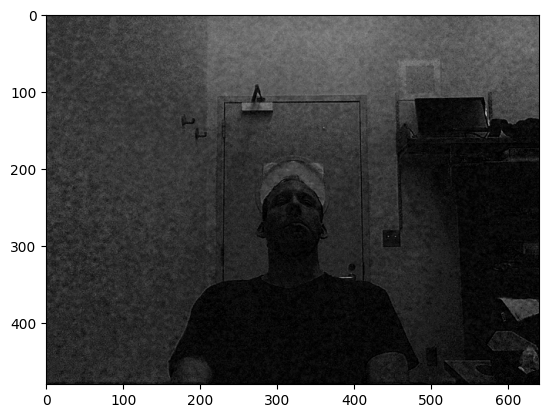

In [48]:
cap.open(0)
image_data = cap.read()
cap.release()

plt.imshow(np.array(image_data[1], dtype = int)[:, :, 0], cmap = "gray")
plt.show()

In [10]:
# We first directly pass the parameter names to signals_update. The function will then return the indices it found that correspond to these parameters. Subsequent calls can be done using the indices, which is faster.
(signals, error) = nanonis.signals_update(["LI Demod 1 X (A)", "LI Demod 1 Y (A)", "LI Demod 2 X (A)", "LI Demod 2 Y (A)"])
signals.pop("dict_name")
signal_indices = []
signal_names = []
signals

{86: ('LI Demod 1 X (A)', -4.835861190113054e-14),
 87: ('LI Demod 1 Y (A)', 2.8194164193519507e-14),
 88: ('LI Demod 2 X (A)', 1.4496479646027016e-13),
 89: ('LI Demod 2 Y (A)', -1.389192173838552e-13)}

In [12]:
nanonis.signals_update([86, 87], name_lookup = True)

({'dict_name': 'signals',
  'LI Demod 1 X (A)': (86, 3.669267784034945e-14),
  'LI Demod 1 Y (A)': (87, -6.536616273212711e-14)},
 False)

In [13]:
nanonis.unlink()

idle


'Nanonis status: idle'

In [20]:
(signals, error) = nanonis.signals_update(["LI Demod 1 X (A)", "LI Demod 1 Y (A)", "LI Demod 2 X (A)", "LI Demod 2 Y (A)"])
signals.pop("dict_name")
signal_indices = []
signal_names = []

for key, value in signals.items():
    if isinstance(key, int):
        signal_indices.append(key)
        signal_names.append(value[0])

print(f"{signals}, {signal_indices}, {signal_names}")

{20: ('LI Demod 1 X (A)', 0.0), 21: ('LI Demod 1 Y (A)', 0.0), 22: ('LI Demod 2 X (A)', 0.0), 23: ('LI Demod 2 Y (A)', 0.0)}, [20, 21, 22, 23], ['LI Demod 1 X (A)', 'LI Demod 1 Y (A)', 'LI Demod 2 X (A)', 'LI Demod 2 Y (A)']


In [11]:
nanonis.unlink()

idle


'Nanonis status: idle'

In [4]:
(gradient_image, error) = data.image_gradient(image)

In [25]:
avg_gradient = np.nanmean(gradient_image.flatten())

In [3]:
data.subtract_background(image)

Attempting a bg subtraction using mode none
Attempting a bg subtraction using mode none 2222


(array([[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        ...,
        [-1.17278276e-09, -1.24273292e-09, -1.28725530e-09, ...,
         -5.57722479e-10, -6.18806006e-10, -5.85340609e-10],
        [-9.35661659e-10, -9.15595655e-10, -1.03504594e-09, ...,
         -4.54642241e-10, -4.52934634e-10, -4.42127918e-10],
        [-9.67777192e-10, -9.84521353e-10, -1.14850840e-09, ...,
         -2.78416595e-10, -2.88916474e-10, -4.46637033e-10]],
       shape=(256, 256)),
 False)

In [4]:
nanonis.unlink()

idle


'Nanonis status: idle'

In [13]:
data.scan_processing_flags.get_all()

{'dict_name': 'processing_flags',
 'direction': 'forward',
 'up_or_down': 'up',
 'channels': [],
 'channel': '',
 'channel_index': None,
 'background': 'none',
 'rotation': False,
 'offset': False,
 'sobel': False,
 'gaussian': False,
 'gaussian_width (nm)': 0,
 'laplace': False,
 'fft': False,
 'normal': False,
 'projection': 're',
 'phase (deg)': 0,
 'min_method': 'full',
 'min_method_value': 0,
 'min_limit': 0,
 'max_method': 'full',
 'max_method_value': 1,
 'max_limit': 1,
 'spec_locations': False,
 'file_name': '',
 'frame': {'dict_name': 'frame',
  'offset (nm)': [0, 0],
  'scan_range (nm)': [0, 0],
  'angle (deg)': 0}}

In [9]:
nanonis.scan_metadata_update()

({'continuous': False,
  'bouncy': True,
  'auto_save': False,
  'series_name': 'unnamed',
  'comment': '',
  'modules_names': [],
  'auto_paste': True,
  'channel_dict': {'Current (A)': 0, 'X (m)': 12, 'Z (m)': 14},
  'signal_dict': {'Current (A)': 0,
   'Interferometer (m)': 1,
   'Input 3 (V)': 2,
   'Input 4 (V)': 3,
   'Input 5 (V)': 4,
   'Input 6 (V)': 5,
   'Input 7 (V)': 6,
   'Input 8 (V)': 7,
   'Bias (V)': 8,
   'Output 2 (V)': 9,
   'Output 3 (V)': 10,
   'Output 4 (V)': 11,
   'X (m)': 12,
   'Y (m)': 13,
   'Z (m)': 14,
   'W (m)': 15,
   'OC D1 Phase (deg)': 16,
   'OC D1 Amplitude (m)': 17,
   'OC M1 Freq. Shift (Hz)': 18,
   'OC M1 Excitation (V)': 19,
   'OC D1 X (m)': 20,
   'OC D1 Y (m)': 21,
   'OC D2 Phase (deg)': 22,
   'OC D2 Amplitude (m)': 23},
  'dict_name': 'scan_metadata'},
 False)

In [7]:
nanonis.unlink()

'Nanonis status: idle'

In [4]:
data.processing_flags.get_all()

{'dict_name': 'processing_flags',
 'direction': 'forward',
 'up_or_down': 'up',
 'channel': 'Z',
 'background': 'none',
 'rotation': False,
 'offset': False,
 'sobel': False,
 'gaussian': False,
 'gaussian_width (nm)': 0,
 'laplace': False,
 'fft': False,
 'normal': False,
 'projection': 're',
 'phase': 0,
 'min_method': 'full',
 'min_method_value': 0,
 'min_limit': 0,
 'max_method': 'full',
 'max_method_value': 1,
 'max_limit': 1,
 'spec_locations': False,
 'file_name': '',
 'frame': {'dict_name': 'frame',
  'offset (nm)': [0, 0],
  'scan_range (nm)': [0, 0],
  'angle (deg)': 0}}

In [27]:
nanonis.unlink()

'Nanonis status: idle'

In [25]:
(tip_status, _) = nanonis.tip_update()
(grid, _) = nanonis.grid_update()

In [26]:
tip_location = [tip_status[f"{dim} (nm)"] for dim in ["x", "y"]]
[blc, tlc] = [grid.get(f"{side}_left_corner (nm)") for side in ["bottom", "top"]]

dist_to_blc = np.linalg.norm(tip_location - blc)
dist_to_tlc = np.linalg.norm(tip_location - tlc)

scan_direction = "up"
if dist_to_tlc < dist_to_blc: scan_direction = "down"
scan_direction

'down'

In [7]:
nanonis.unlink()

'Nanonis status: idle'

In [5]:
(start_parameters, _) = nanonis.initialize()
scan_metadata = start_parameters.get("scan_metadata")

signal_dict = scan_metadata.get("signal_dict")
feedback_channel_indices = [signal_dict.get(channel_name) for channel_name in ["Z (m)"]]

In [6]:
feedback_channel_indices

[14]

In [3]:
signal_dict = scan_metadata.get("signal_dict")

In [22]:
scan_metadata

{'continuous': False,
 'bouncy': True,
 'auto_save': False,
 'series_name': 'unnamed',
 'comment': '',
 'modules_names': [],
 'auto_paste': True,
 'channel_dict': {'Current (A)': 0, 'Interferometer (m)': 1, 'X (m)': 12},
 'signal_dict': {'Current (A)': 0,
  'Interferometer (m)': 1,
  'Input 3 (V)': 2,
  'Input 4 (V)': 3,
  'Input 5 (V)': 4,
  'Input 6 (V)': 5,
  'Input 7 (V)': 6,
  'Input 8 (V)': 7,
  'Bias (V)': 8,
  'Output 2 (V)': 9,
  'Output 3 (V)': 10,
  'Output 4 (V)': 11,
  'X (m)': 12,
  'Y (m)': 13,
  'Z (m)': 14,
  'W (m)': 15,
  'OC D1 Phase (deg)': 16,
  'OC D1 Amplitude (m)': 17,
  'OC M1 Freq. Shift (Hz)': 18,
  'OC M1 Excitation (V)': 19,
  'OC D1 X (m)': 20,
  'OC D1 Y (m)': 21,
  'OC D2 Phase (deg)': 22,
  'OC D2 Amplitude (m)': 23},
 'dict_name': 'scan_metadata'}

In [25]:
mla.set_amp_mV(200)

In [27]:
mla.set_f1(10)

In [29]:
mla.mla.lockin.start_lockin()

In [14]:
nanonis.unlink()

'Nanonis status: idle'

In [14]:
(poke_area, error) = nanonis.frame_update()

In [15]:
[width_nm, height_nm] = poke_area.get("scan_range (nm)")
[x_nm, y_nm] = poke_area.get("offset (nm)")

In [16]:
rng = np.random.default_rng()
poke_locations = rng.uniform(low = [x_nm - .5 * width_nm, y_nm - .5 * height_nm], high = [x_nm + .5 * width_nm, y_nm + .5 * height_nm], size = (5, 2))

In [17]:
poke_locations

array([[-855.66624517,  540.47821901],
       [-776.26851059,  509.00729521],
       [-887.63554415,  522.54214692],
       [-706.33303273,  466.14514091],
       [-850.35726051,  466.24294549]])

In [18]:
for iteration, location in enumerate(poke_locations):
    nanonis.tip_update({"offset (nm)": location})
    nanonis.tip_update(verbose = False)
    nanonis.shape_tip()

In [19]:
nanonis.unlink()

'Nanonis status: idle'

In [3]:
nhw.set_tip_shaper({"lift_bias (V)": 6, "poke_depth (nm)": -2})

{'lift_bias (V)': 6,
 'poke_depth (nm)': -2,
 'switch_off_delay (s)': 0.05000000074505806,
 'change_bias': False,
 'poke_bias (V)': 2.0,
 'poke_time (s)': 0.20000000298023224,
 'bias_settling_time (s)': 0.10000000149011612,
 'lift_height (nm)': 4.999999969612645,
 'lift_time (s)': 1.0,
 'end_wait_time (s)': 0.10000000149011612,
 'restore_feedback': False}

In [12]:
chunks = [response[index : index + 4] for index in range(0, len(response), 4)]
nhw.conv.hex_to_float32(chunks[0])
bool(nhw.conv.hex_to_uint32(chunks[1]))
[nhw.conv.hex_to_float32(chunks[i + 2]) for i in range(8)]

[2.0,
 -1.000000013351432e-10,
 0.20000000298023224,
 2.0,
 0.10000000149011612,
 4.999999969612645e-09,
 1.0,
 0.10000000149011612]

In [10]:
nhw.conv.make_header('Bias.Get', body_size = 4)

'426961732e4765740000000000000000000000000000000000000000000000000000000400010000'

In [4]:
nanonis.unlink()

'Nanonis status: idle'

In [9]:
nanonis.unlink()

'Nanonis status: idle'

In [2]:
mla.link()

Check connection to MLA at 192.168.236.50
Connection ok.
Setting up MLA...
[]
[]
[]
['killall: server: no process killed\n']
192.168.236.50: Uploading files...
Uploading file: C:\IMP\imp_mla-4.6-any\mlaapi\firmware\server
   Destination   :/tmp/server
Done, uploaded 52044 bytes.
[]
[]
chmod +x /tmp/server
[]
[]
Uploading file: C:\Users\LTAFM\AppData\Local\Temp\FPGA_210_32_32_201712.top.bit.bin
   Destination   :/tmp/FPGA_210_32_32_201712.top.bit.bin
Done, uploaded 4045564 bytes.
[]
[]
['net.core.rmem_max = 16777216\n']
[]
/tmp/server > /dev/null 2>&1 &
['1\n']
[]
Reading: /mnt/mmc/settings/hconfig.ini
Done setting up MLA.
Connecting to MLA server...
S: Connected..
Configuring hardware.

S: Reloading FPGA with: /tmp/FPGA_210_32_32_201712.top.bit.bin

S: Reloading FPGA with: /tmp/FPGA_210_32_32_201712.top.bit.bin

Starting lockin.
Starting ARB.
Starting OSC.
Starting feedback.
Loading calibration: factory.ini
Startup sequence finished.
----------------------------------------------------

In [8]:
mla.unlink()

192.168.236.50: ok quit


In [14]:
mla.set_base_frequency(220)

In [6]:
amplitudes = np.zeros(shape = mla.lockin.nr_output_freq, dtype = int) # List of 32 zeros
amplitudes[0] = .5
mla.lockin.set_amplitudes(amplitudes)

In [7]:
mla.lockin.get_amplitudes()

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [27]:
(pixels, uint8_array) = mla.lockin.get_pixels(2)

np.average(pixels, axis = 1)

array([-1.36125983e-04+8.01878176e-05j, -1.36125983e-04+8.01878176e-05j,
       -4.30909870e-05+7.08964866e-05j, -1.78260957e-04-8.33585090e-05j,
        6.94804830e-05+6.07279144e-05j, -2.33567642e-05+7.47952859e-05j,
       -4.32423881e-05+5.35024248e-05j, -2.84616653e-06+7.18515865e-05j,
       -2.36954477e-05+8.22601205e-05j,  2.54542268e-05+3.05314681e-06j,
       -2.26950813e-05+2.14563988e-06j,  3.15111517e-05+4.27098935e-05j,
        1.28594716e-05-3.51343187e-05j, -3.00860779e-05-6.12782422e-06j,
        6.68115245e-05-1.24339146e-05j,  2.51961004e-05-3.82519813e-05j,
        4.03634964e-05+1.18884348e-05j, -1.82402537e-05+8.86429493e-05j,
       -3.91917789e-06-2.57692487e-05j,  3.02946556e-05+2.33449250e-05j,
        1.26763710e-05+3.34080610e-05j, -1.30914868e-05+3.81087005e-05j,
       -2.86215223e-06+7.76258668e-05j, -8.11368383e-06-3.40739461e-05j,
        1.60351189e-05+8.20906338e-06j, -2.17623774e-05+2.64245408e-05j,
       -1.82699066e-05+2.81737646e-05j, -2.72914388

In [ ]:
mla.unlink()

In [51]:
mla_loader.mla.disconnect()

192.168.236.50: ok quit


In [15]:
(bias, error) = nanonis.bias_update()
V_feedback = bias.get("V_nanonis (V)")
V_feedback

In [6]:
(scan_image, error) = nanonis.scan_update(channel = 14, backward = False, verbose = False)
nan_mask = np.isnan(scan_image)
scan_finished = not bool(np.any(nan_mask))
scan_finished

True

In [30]:
nanonis.unlink()

'Nanonis status: idle'

In [29]:
[x, y] = 2 * np.random.random(2) - 1
print(x)
print(y)

-0.9957694628573761
-0.5000924538264178


In [16]:
(scan_image, _) = nanonis.scan_update(14, False)

In [18]:
(grid, _) = nanonis.grid_update()

In [19]:
nanonis.find_scan_image_minmax(scan_image, grid)

{'minimum': {'pixel': np.int64(0),
  'line': np.int64(4),
  'value': np.float64(-3.227213087089421e-09),
  'x (nm)': np.float64(215.40064316645623),
  'y (nm)': np.float64(384.75051881952083)},
 'maximum': {'pixel': np.int64(63),
  'line': np.int64(46),
  'value': np.float64(-2.3051215340471106e-09),
  'x (nm)': np.float64(215.40064316645623),
  'y (nm)': np.float64(384.75051881952083)}}

In [17]:
scan_image.shape

(64, 64)

(64, 64)
214.97311798989745, 383.57590305067714


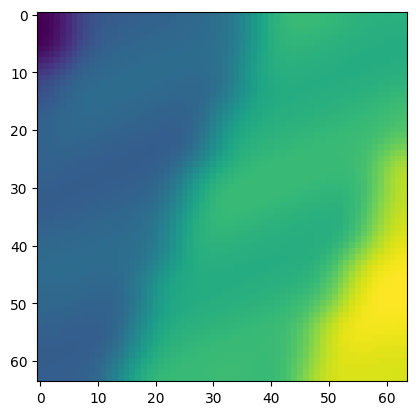

In [ ]:
print(scan_image.shape)

blurred_image = gaussian_filter(scan_image, 3)
max_line, max_pixel = np.unravel_index(blurred_image.argmax(), blurred_image.shape)
max_value = blurred_image[max_line, max_pixel]
[x_max_nm, y_max_nm] = nanonis.coords_of_grid_pixel(grid_dict = grid, indices = [max_pixel, max_line])

print(f"{x_max_nm}, {y_max_nm}")

plt.imshow(blurred_image)
plt.show()

In [35]:
nhw.get_scan_data(14)

{'scan_data': array([[-3.20950666e-09, -3.18933902e-09, -3.15648996e-09, ...,
         -2.64639732e-09, -2.59891575e-09, -3.28204375e-09],
        [-3.17126081e-09, -3.29704175e-09, -3.15774118e-09, ...,
         -2.62254884e-09, -2.57294452e-09, -3.13118176e-09],
        [-3.19937454e-09, -3.28723782e-09, -3.27164784e-09, ...,
         -2.62241584e-09, -2.59622301e-09, -3.19641535e-09],
        ...,
        [-3.01288350e-09, -3.05251668e-09, -2.89376589e-09, ...,
         -2.50822474e-09, -2.33467801e-09, -3.05251313e-09],
        [-2.91237190e-09, -2.93517499e-09, -2.92747759e-09, ...,
         -2.39247044e-09, -2.37136732e-09, -2.95819191e-09],
        [-3.00179726e-09, -2.89038327e-09, -2.93273827e-09, ...,
         -2.28297314e-09, -2.44911758e-09,  1.40129846e-45]],
       shape=(64, 64)),
 'channel_name': 'Z (m)',
 'scan_direction': 'down'}

In [11]:
nanonis.unlink()

'Nanonis status: idle'

In [5]:
nhw.get_scan_buffer()
nhw.set_scan_buffer(channel_indices = [0, 1, 2, 3, 4])

In [16]:
(scan_metadata, error) = nanonis.scan_metadata_update()
signal_dict = scan_metadata["signal_dict"]

feedback_channel_indices = [signal_dict.get(channel_name) for channel_name in ["Z (m)"]]
feedback_channel_indices = [index for index in feedback_channel_indices if index is not None]
constant_height_channel_indices = [signal_dict.get(channel_name) for channel_name in ["Lockin Demod 1 X (A)", "Lockin Demod 1 Y (A)", "Current (A)"]]
constant_height_channel_indices = [index for index in constant_height_channel_indices if index is not None]

constant_height_channel_indices
print("Switching to constant heigh mode")
nhw.set_scan_buffer(channel_indices = constant_height_channel_indices)
time.sleep(2)
print("Switching to constant heigh mode")
nhw.set_scan_buffer(channel_indices = feedback_channel_indices)

Switching to constant heigh mode
Switching to constant heigh mode


In [16]:
nanonis.get_parameter_values(["LI Demod 1 X (A)", "LI Demod 1 Y (A)", "LI Demod 2 X (A)", "LI Demod 2 Y (A)"], unlink = False)

({'LI Demod 1 X (A)': 'not found',
  'LI Demod 1 Y (A)': 'not found',
  'LI Demod 2 X (A)': 'not found',
  'LI Demod 2 Y (A)': 'not found'},
 False)

In [26]:
nanonis.unlink()

'Nanonis status: idle'

In [6]:
nhw.version = 15000

In [5]:
(scan_metadata, error) = nanonis.scan_metadata_update()
scan_channels = scan_metadata["channel_dict"]

In [13]:
list(scan_channels.values())[0]

0

In [14]:
nanonis.unlink()

'Nanonis status: idle'

In [4]:
nhw.get_signals_in_slots()

{'names': ['Current (A)',
  'Interferometer (m)',
  'Input 3 (V)',
  'Input 4 (V)',
  'Input 5 (V)',
  'Input 6 (V)',
  'Input 7 (V)',
  'Input 8 (V)',
  'Bias (V)',
  'Output 2 (V)',
  'Output 3 (V)',
  'Output 4 (V)',
  'X (m)',
  'Y (m)',
  'Z (m)',
  'W (m)',
  'OC D1 Phase (deg)',
  'OC D1 Amplitude (m)',
  'OC M1 Freq. Shift (Hz)',
  'OC M1 Excitation (V)',
  'OC D1 X (m)',
  'OC D1 Y (m)',
  'OC D2 Phase (deg)',
  'OC D2 Amplitude (m)'],
 'indices': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81]}

In [7]:
nanonis.lockin_update({"modulator_1": {"on": False}})

({'dict_name': 'lockin',
  'modulator_1': {'on': False,
   'frequency (Hz)': 600.0,
   'amplitude (mV)': 500.0,
   'phase (deg)': 0.0},
  'modulator_2': {'on': False,
   'frequency (Hz)': 1000.0,
   'amplitude (mV)': 1000.0,
   'phase (deg)': 0.0}},
 False)

In [11]:
"V_nanonis (V)".split()[0]

'V_nanonis'

In [8]:
nanonis.unlink()

'Nanonis status: idle'

In [2]:
grid_data, _ = nanonis.grid_update(unlink = True)
[x_grid, y_grid] = [grid_data.get(attribute) for attribute in ["x_grid", "y_grid"]]

In [3]:
xy_lists, _ = nanonis.grids_to_lists(grid_data, direction = "up")
xy_list_hex = xy_lists.get("xy_list")

In [8]:
#nhw.link()
for iter in range(len(xy_list_hex)):
    nhw.set_xy(xy_list_hex[iter])

In [18]:
nhw.set_xy_nm([0, 0])

In [3]:
nanonis.unlink()

'Nanonis status: idle'

In [3]:
nhw.set_lockin(1, False)

b'\x00\x00\x00\x00\x00\x00\x00\x00'

In [5]:
nhw.connect()
nhw.get_signal_names()

['Current (A)',
 'Input 2 (V)',
 'Temperature 1 (V)',
 'Temperature 2 (V)',
 'Input 5 (V)',
 'Input 6 (V)',
 'Input 7 (V)',
 'Input 8 (V)',
 'Input 9 (V)',
 'Input 10 (V)',
 'Input 11 (V)',
 'Input 12 (V)',
 'Input 13 (V)',
 'Input 14 (V)',
 'Input 15 (V)',
 'Input 16 (V)',
 'Input 17 (V)',
 'Input 18 (V)',
 'Input 19 (V)',
 'Input 20 (V)',
 'Input 21 (V)',
 'Input 22 (V)',
 'Input 23 (V)',
 'Input 24 (V)',
 'Bias (V)',
 'Output 2 (V)',
 'T1 Supply voltage (V)',
 'T2 Supply voltage (V)',
 'X (m)',
 'Y (m)',
 'Z (m)',
 'M8: Current (A)',
 'Output 9 (V)',
 'Output 10 (V)',
 'Output 11 (V)',
 'Output 12 (V)',
 'Output 13 (V)',
 'Output 14 (V)',
 'Output 15 (V)',
 'Output 16 (V)',
 'Output 17 (V)',
 'Output 18 (V)',
 'Output 19 (V)',
 'Output 20 (V)',
 'Output 21 (V)',
 'Output 22 (V)',
 'Output 23 (V)',
 'Output 24 (V)',
 'Fast Output 3 (V)',
 'Output 26 (V)',
 'Output 27 (V)',
 'Output 28 (V)',
 'Output 29 (V)',
 'Output 30 (V)',
 'Output 31 (V)',
 'Output 32 (V)',
 'Output 33 (V)',
 'Ou

In [8]:
(md, error) = nanonis.scan_metadata_update(auto_disconnect = False)

In [9]:
signal_dict = md.get("signal_dict")
temp_index = signal_dict.get("Temperature 1 (V)")
nhw.get_signal_value(temp_index)

1.6336807012557983

In [10]:
signal_dict

{'Current (A)': 0,
 'Input 2 (V)': 1,
 'Temperature 1 (V)': 2,
 'Temperature 2 (V)': 3,
 'Input 5 (V)': 4,
 'Input 6 (V)': 5,
 'Input 7 (V)': 6,
 'Input 8 (V)': 7,
 'Input 9 (V)': 8,
 'Input 10 (V)': 9,
 'Input 11 (V)': 10,
 'Input 12 (V)': 11,
 'Input 13 (V)': 12,
 'Input 14 (V)': 13,
 'Input 15 (V)': 14,
 'Input 16 (V)': 15,
 'Input 17 (V)': 16,
 'Input 18 (V)': 17,
 'Input 19 (V)': 18,
 'Input 20 (V)': 19,
 'Input 21 (V)': 20,
 'Input 22 (V)': 21,
 'Input 23 (V)': 22,
 'Input 24 (V)': 23,
 'Bias (V)': 24,
 'Output 2 (V)': 25,
 'T1 Supply voltage (V)': 26,
 'T2 Supply voltage (V)': 27,
 'X (m)': 28,
 'Y (m)': 29,
 'Z (m)': 30,
 'M8: Current (A)': 31,
 'Output 9 (V)': 32,
 'Output 10 (V)': 33,
 'Output 11 (V)': 34,
 'Output 12 (V)': 35,
 'Output 13 (V)': 36,
 'Output 14 (V)': 37,
 'Output 15 (V)': 38,
 'Output 16 (V)': 39,
 'Output 17 (V)': 40,
 'Output 18 (V)': 41,
 'Output 19 (V)': 42,
 'Output 20 (V)': 43,
 'Output 21 (V)': 44,
 'Output 22 (V)': 45,
 'Output 23 (V)': 46,
 'Output 2

In [11]:
nhw.withdraw()

In [5]:
nanonis.disconnect()

In [13]:
nhw.connect()
props = nhw.get_scan_props()
buffer = nhw.get_scan_buffer() # The buffer has the number of channels, indices of these channels, and pixels and lines
channel_indices = buffer["channel_indices"]

signal_names = nhw.get_signal_names()
channel_dict = {signal_names[index]: index for index in buffer.get("channel_indices")}
nhw.disconnect()

scan_metadata = props | buffer | {"signal_names": signal_names, "channel_dict": channel_dict}

[print(f"{key}: {value}") for key, value in scan_metadata.items()]

continuous: False
bouncy: False
auto_save: False
series_name: 260103
comment: 
modules_names: []
auto_paste: True
num_channels: 4
channel_indices: [0, 30, 86, 87]
pixels: 304
lines: 304
pixel_ratio: 1.0
signal_names: ['Current (A)', 'Input 2 (V)', 'Temperature 1 (V)', 'Temperature 2 (V)', 'Input 5 (V)', 'Input 6 (V)', 'Input 7 (V)', 'Input 8 (V)', 'Input 9 (V)', 'Input 10 (V)', 'Input 11 (V)', 'Input 12 (V)', 'Input 13 (V)', 'Input 14 (V)', 'Input 15 (V)', 'Input 16 (V)', 'Input 17 (V)', 'Input 18 (V)', 'Input 19 (V)', 'Input 20 (V)', 'Input 21 (V)', 'Input 22 (V)', 'Input 23 (V)', 'Input 24 (V)', 'Bias (V)', 'Output 2 (V)', 'T1 Supply voltage (V)', 'T2 Supply voltage (V)', 'X (m)', 'Y (m)', 'Z (m)', 'M8: Current (A)', 'Output 9 (V)', 'Output 10 (V)', 'Output 11 (V)', 'Output 12 (V)', 'Output 13 (V)', 'Output 14 (V)', 'Output 15 (V)', 'Output 16 (V)', 'Output 17 (V)', 'Output 18 (V)', 'Output 19 (V)', 'Output 20 (V)', 'Output 21 (V)', 'Output 22 (V)', 'Output 23 (V)', 'Output 24 (V)', 

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [ ]:
nanonis.connect() 
buffer = nhw.get_scan_buffer()

In [6]:
props = nhw.get_scan_props()
buffer = nhw.get_scan_buffer() # The buffer has the number of channels, indices of these channels, and pixels and lines
channel_indices = buffer["channel_indices"]

{'num_channels': 4,
 'channel_indices': [0, 30, 86, 87],
 'pixels': 784,
 'lines': 784,
 'pixel_ratio': 1.0}

In [2]:
s_md = nanonis.scan_metadata_update()

In [3]:
s_md

(None, ValueError("invalid literal for int() with base 16: '0x'"))

In [16]:
{names[index]: index for index in buffer.get("channel_indices")}

{'Current (A)': 0, 'Z (m)': 30, 'LI Demod 1 X (A)': 86, 'LI Demod 1 Y (A)': 87}

In [10]:
print([name for name in [names[i] for i in [0, 30, 86, 87]]])

['Current (A)', 'Z (m)', 'LI Demod 1 X (A)', 'LI Demod 1 Y (A)']


In [10]:
command = nhw.conv.make_header('Signals.NamesGet', body_size = 0)
print(command)

nhw.send_command(command)
response = nhw.receive_response()
time.sleep(1)

print(response)

5369676e616c732e4e616d6573476574000000000000000000000000000000000000000000010000
b'\x00\x00\t\x06\x00\x00\x00\x80\x00\x00\x00\x0bCurrent (A)\x00\x00\x00\x0bInput 2 (V)\x00\x00\x00\x11Temperature 1 (V)\x00\x00\x00\x11Temperature 2 (V)\x00\x00\x00\x0bInput 5 (V)\x00\x00\x00\x0bInput 6 (V)\x00\x00\x00\x0bInput 7 (V)\x00\x00\x00\x0bInput 8 (V)\x00\x00\x00\x0bInput 9 (V)\x00\x00\x00\x0cInput 10 (V)\x00\x00\x00\x0cInput 11 (V)\x00\x00\x00\x0cInput 12 (V)\x00\x00\x00\x0cInput 13 (V)\x00\x00\x00\x0cInput 14 (V)\x00\x00\x00\x0cInput 15 (V)\x00\x00\x00\x0cInput 16 (V)\x00\x00\x00\x0cInput 17 (V)\x00\x00\x00\x0cInput 18 (V)\x00\x00\x00\x0cInput 19 (V)\x00\x00\x00\x0cInput 20 (V)\x00\x00\x00\x0cInput 21 (V)\x00\x00\x00\x0cInput 22 (V)\x00\x00\x00\x0cInput 23 (V)\x00\x00\x00\x0cInput 24 (V)\x00\x00\x00\x08Bias (V)\x00\x00\x00\x0cOutput 2 (V)\x00\x00\x00\x15T1 Supply voltage (V)\x00\x00\x00\x15T2 Supply voltage (V)\x00\x00\x00\x05X (m)\x00\x00\x00\x05Y (m)\x00\x00\x00\x05Z (m)\x00\x00\x00\x0fM8: Cur

In [7]:
nanonis.disconnect()